# Appendix - Datasets: Sources and cleanup

Multiple data sources were combined to create the final dataset used in the analysis. The following desctibes the data's sources, any initial processing that was required on the data prior to merging into a single dataset, and the raional and process of reducing the dataset size.



In [1]:
# load libraries
import pandas as pd

# For Scraping
import requests # package for http requests
import bs4 # package for html parsing

## For Visualizing
import matplotlib.pyplot as plt

---

## Datasets and Data Cleanup

### State Name and Abbreviations

State names, and state abbreviation codes, were grabbed from Jason Ong on Github (https://github.com/jasonong/List-of-US-States). This dataset is used as a helper tool to normalize data between other datasets and not actuallly used in the study. Some of the datasets used in this study used full state names in their data, while others used abbreviations—this dataset helped standardixe the format.

In [2]:
# Import state names and abbreviations
state_codes = pd.read_csv("state_codes.csv")

---

### Zillow Housing Price Data
Zillow provides time-series data of house sale prices in the United States at (https://www.zillow.com/research/data/).
This is using their "ZHVI Single Family Homes Time Series($)" Dataset for US Cities.

#### Data Cleanup
A preliminary attempt to merge the Zillow dataset with a list of college towns dataset produced numerous (83) unmatched entries. A frequent mismatch appears to be the inclusion of "Town of ..." or "Town of ...", as in "Town Of Ithaca" and "Town of Oswego", in the Zillow data. This was programmatically removed.

~~In addition, several columns were dropped or renamed for consistency with other datasets, and a new column was created which contains both city and state to facility filtering across multiple datasets.~~

In [3]:
# Helper Function

# Returns a string with all substrings in a list removed from it
def remove_all(list, str):
    for substr in list:
        index = 0
        length = len(substr)
        while str.find(substr) != -1:
            index = str.find(substr)
            str = str[0:index] + str[index+length:]
    return str

In [4]:
# Import data
zillow = pd.read_csv("zillow-sfh-city.csv")

# Rename Columns for consistency
zillow = zillow.rename(columns = {'RegionName':'city'})
zillow = zillow.rename(columns = {'StateName':'state_code'})

# Drop unneeded columns
zillow = zillow.drop(columns=['RegionID', 'RegionType','CountyName','Metro', 'State'])

# Strip "Town Of " from city names
zillow['city'] = zillow.apply(lambda row : remove_all( ["Town Of ", "Town of "], row['city'] ), axis = 1)

# fill empty cells with zeroes and convert to int
zillow.loc[:,'1996-01-31': ] = zillow.loc[:,'1996-01-31': ].fillna(0).astype(int)

# Create a 'city_state' column which is helpful in some preliminary analysis
zillow['city_state'] = zillow.city + ', ' + zillow.state_code

In [5]:
# Save data to csv
zillow.to_csv('zillow-cleaned.csv')

---

### Census Population Data
The US Census provides time-series data for populations of Incorporated Places in the United States from 2010 to 2019 (https://www.census.gov/data/tables/time-series/demo/popest/2010s-total-cities-and-towns.html).

#### Data Cleanup
A preliminary examination of the data showed that locations were a single string containing the place name, type, and state. This data needed to be parsed and split into separate columns to merge it with other datasets.

Further inspection also revealed numerous inconsistencies between names in this set and others. These had to be individually investigated, compared, and corrected. This involved freequent merging and examing lists of remainders, looking up cities on google maps, and guessing and doing searhes on alternate spellings.

Lastly, population numbers were stored as strings with comma separated thousands. These needed to be converted to integers.

One additional observation that may still need to be cleaned up—There are 16 instances where a state has 2 or more rows with the same 'city' name. These rows always have different 'types' eg. city, town, borough, and different population sizes. Should duplicates be merged or dropped? It's unclear which location is being represented in it's matching Zillow sale price data.



In [6]:
# Helper functions to clean up original census population data
# Raw data for 'Geographic Area' is formatted as "city_name city_type, state_name"

def extractState(string):
    # Returns State name from raw 'Geographic Area'
    length = len(string)
    index = string.rfind(",")
    str = string[index+2:length]
    return str

def extractCity(string):
    # Returns City name from raw 'Geographic Area'
    index = string.rfind(",")
    space = string.rfind(" ", 0, index)
    str = string[0:space]
    return str

def extractType(string):
    # Return type from raw
    # Could be City, Town, Village, Borough
    index = string.rfind(",")
    space = string.rfind(" ", 0, index)
    str = string[space+1:index]
    return str

In [7]:
# Import data
population = pd.read_csv("census-population.csv")

# Create state column
population['state_name'] = population.apply(lambda row : extractState(row['Geographic Area']), axis = 1)

# Create type column
population['city_type'] = population.apply(lambda row : extractType(row['Geographic Area']), axis = 1)

# Change Geographic Area to city (name)
population['Geographic Area'] = population.apply(lambda row : extractCity(row['Geographic Area']), axis = 1)
population = population.rename(columns = {'Geographic Area':'city'})

# Rename Columns for consistency
population = population.rename(columns = {'2010':'pop_2010'})
population = population.rename(columns = {'2011':'pop_2011'})
population = population.rename(columns = {'2012':'pop_2012'})
population = population.rename(columns = {'2013':'pop_2013'})
population = population.rename(columns = {'2014':'pop_2014'})
population = population.rename(columns = {'2015':'pop_2015'})
population = population.rename(columns = {'2016':'pop_2016'})
population = population.rename(columns = {'2017':'pop_2017'})
population = population.rename(columns = {'2018':'pop_2018'})
population = population.rename(columns = {'2019':'pop_2019'})

# Drop uneeded columns
population = population.drop(columns=['Census','Estimates Base'])


# Cleanup
# Strip " city and" from city names
population['city'] = population.apply(lambda row : remove_all( [" city and"], row['city'] ), axis = 1)

# Manual renames
population.loc[population.city=='St. Leo', 'city'] = 'Saint Leo'
population.loc[population.city=='St. Augustine', 'city'] = 'Saint Augustine'
population.loc[population.city=='St. Leo', 'city'] = 'Saint Leo'
population.loc[population.city=='St. Petersburg', 'city'] = 'Saint Petersburg'
population.loc[population.city=='St. Cloud', 'city'] = 'Saint Cloud'
population.loc[population.city=='St. Joseph', 'city'] = 'Saint Joseph'
population.loc[population.city=='St. Peter', 'city'] = 'Saint Peter'
population.loc[population.city=='St. George', 'city'] = 'Saint George'
population.loc[population.city=='Port St. Lucie', 'city'] = 'Port Saint Lucie'
population.loc[population.city=='North Bennington', 'city'] = 'Bennington'
population.loc[population.city=='Nashville-Davidson metropolitan government', 'city'] = 'Nashville'
population.loc[population.city=='McKenzie', 'city'] = 'Mc Kenzie'
population.loc[population.city=='Dublin', 'city'] = 'Upper Dublin Township'
population.loc[population.city=='Shippensburg', 'city'] = 'Shippensburg Township'
population.loc[population.city=='Princeton, New Jerse', 'city'] = 'Princeton'
population.loc[population.city=='Butte-Silver Bow', 'city'] = 'Butte'
population.loc[population.city=='Saint Paul', 'city'] = 'St. Paul'
population.loc[population.city=='Bridgewater', 'city'] = 'Bridgewater Town'
population.loc[population.city=='Louisville/Jefferson County metro government', 'city'] = 'Louisville'
population.loc[population.city=='Lexington-Fayette urban', 'city'] = 'Lexington'
population.loc[population.city=='DeKalb', 'city'] = 'Dekalb'
population.loc[population.city=='Boise City', 'city'] = 'Boise'
population.loc[population.city=='Macon-Bibb', 'city'] = 'Macon'
population.loc[population.city=='Augusta-Richmond County consolidated government', 'city'] = 'Augusta'
population.loc[population.city=='Athens-Clarke County unified government', 'city'] = 'Athens'
population.loc[population.city=='DeLand', 'city'] = 'Deland'


# add state codes
population = pd.merge(population, state_codes, how='outer', on='state_name')
population['city_state'] = population.city + ', ' + population.state_code

In [8]:
# convert values from comma separated thousands strings to integers
for column in population.loc[:,'pop_2010':'pop_2019'].columns.tolist():
    population[column] = population[column].apply( lambda s : remove_all( [","], s) ).fillna(0).astype(int)

In [9]:
# Note potential confusion.
# There are 16 instances where a state has 2 or more rows with the same 'city' name.
# These rows always have different 'types' eg. city, town, borough
dupes = population.city_state.value_counts() > 1
print("Duplicate City Names within the same State:")
print(dupes[dupes==True])

Duplicate City Names within the same State:
Oakwood, OH          True
Coaldale, PA         True
Windsor, IL          True
Liberty, PA          True
Lakeside, TX         True
Superior, WI         True
Reno, TX             True
St. Anthony, MN      True
Oak Ridge, TX        True
Pewaukee, WI         True
Centerville, PA      True
Newburg, PA          True
Wilmington, IL       True
Jefferson, PA        True
Franklin, PA         True
Pleasantville, PA    True
Name: city_state, dtype: bool


In [10]:
# Drop unneeded columns
population = population.drop(columns=['state_name', 'city_type'])

In [11]:
# Save data to csv
population.to_csv('population-cleaned.csv')

---

### College Towns Data
A list of college towns in the United States scraped from https://en.wikipedia.org/wiki/List_of_college_towns. The initial scrape data needs to be filtered to just cities in the United States (as opposed to the entire world). From there, the data is parsed to remove extra text and information and create a list of city and state pairs that can later be used to create a subset of housing price data that only includes college towns.

#### Data Cleanup

A preliminary attempt to merge the College Town with the Zillow and the Census datasets left many unmatch entries.
 
On examination, these mismatches where do to several different causes.

In some instances, the content formating in the web document changed for a small chunk of the content.  This error had do be manually corrected.

Some data mismatch the result of naming convention differences such as "St. Peter" as opposed to "Saint Peter." Others were the result of differing levels of specificity, such as "Downtown Phoenix" rather than "Phoenix."

Finally, some cities in the College Town list were too small to appear in either of the other datasets.

In [12]:
ctowns_web = 'https://en.wikipedia.org/wiki/List_of_college_towns'
ctownsResponse = requests.get(ctowns_web)

In [13]:
## parse the raw wiki HTML into a BeautifulSoup object
soup = bs4.BeautifulSoup(ctownsResponse.text, 'html.parser')

In [14]:
# Save the data to a file to process
ctowns_file = 'wikipedia_college_towns_scrape.html'

with open(ctowns_file, mode='w', encoding='utf-8') as f:
    f.write(ctownsResponse.text)

In [15]:
outer = soup.find("div", {"class": "mw-parser-output"})

In [16]:
# Process the text and extract usable data
# City, State, list of Colleges city, Count of colleges in city
# note: no current plans to use college names but I'm keeping the data incase it's usefull laterv

ctowns_list = []
country = ""
state = ""
city = ""
tags = outer.findChildren(['h2', 'h3', 'ul'], recursive=False)
for tag in tags:
    if tag.name=="h2":
        country = remove_all(["College towns in","[edit]"], tag.text).strip(' ')
    if country=="the United States":
        # Only process info in the US section
        if tag.name=="h3":
            state = remove_all(["[edit]"], tag.text).strip(' ')
        if tag.name=="ul":
            list_items = tag.findChildren('li', recursive=False)
            for li in list_items:
                # first link in the list is the city, subsequent links are the schools
                city = li.a.text
                colleges = []
                links = li.find_all('a')
                i = 1
                while i < len(links):
                    college = links[i].text
                    if college.find('[') == -1: 
                        #ignores subscript endnote links
                        colleges.append(college)
                    i = i + 1
                ctowns_list.append([city, state, colleges, len(colleges)])


In [17]:
# Make a datafram from the college town list
ctowns = pd.DataFrame( ctowns_list ,columns=['city', 'state_name', 'colleges', 'colleges_count'] )

In [18]:
# Manual Cleanup
# Renames
ctowns.loc[ctowns.city=='York, Nebraska', 'city'] = 'York'
ctowns.loc[ctowns.city=='St. Augustine', 'city'] = 'Saint Augustine'
ctowns.loc[ctowns.city=='St. Leo', 'city'] = 'Saint Leo'
ctowns.loc[ctowns.city=='St. Petersburg', 'city'] = 'Saint Petersburg'
ctowns.loc[ctowns.city=='St. Cloud', 'city'] = 'Saint Cloud'
ctowns.loc[ctowns.city=='St. Joseph', 'city'] = 'Saint Joseph'
ctowns.loc[ctowns.city=='St. Peter', 'city'] = 'Saint Peter'
ctowns.loc[ctowns.city=='St. George', 'city'] = 'Saint George'
ctowns.loc[ctowns.city=='Port St. Lucie', 'city'] = 'Port Saint Lucie'
ctowns.loc[ctowns.city=='Ewing', 'city'] = 'Ewing Township'
ctowns.loc[ctowns.city=='West Point', 'city'] = 'Highland Falls'
ctowns.loc[ctowns.city=='McKenzie', 'city'] = 'Mc Kenzie'
ctowns.loc[ctowns.city=='Perrysburg Township', 'city'] = 'Perrysburg'
ctowns.loc[ctowns.city=='DeLand', 'city'] = 'Deland'
ctowns.loc[ctowns.city=='DeKalb', 'city'] = 'Dekalb'
ctowns.loc[ctowns.city=='Shippensburg', 'city'] = 'Shippensburg Township'
ctowns.loc[ctowns.city=='Abington', 'city'] = 'Abington Township'

# Move to nearest neighbor
ctowns.loc[ctowns.city=='Notre Dame', 'city'] = 'South Bend'
ctowns.loc[ctowns.city=='Institute', 'city'] = 'Dunbar'
ctowns.loc[ctowns.city=='Genoa Township', 'city'] = 'Howell'
ctowns.loc[ctowns.city=='Wilberforce', 'city'] = 'Xenia'
ctowns.loc[ctowns.city=='Center Valley', 'city'] = 'Coopersburg'
ctowns.loc[ctowns.city=='Annville', 'city'] = 'Lebanon'


# Examples of cities 
# Tougaloo, MS -> Jackson, MI
# Lower Merion Township, PA -> Philadelphia
# ctowns.loc[ctowns.city=='Villanova', 'city'] = 'Philadelphia'

# metro areas
ctowns.loc[ctowns.city=='Binghamton', 'city'] = 'Johnson City'
ctowns.loc[ctowns.city=='West Hartford', 'city'] = 'Hartford'

## Manually split these:
# The Colleges of Worcester Consortium:
# Dudley (Nichols College)
# North Grafton (Cummings School of Veterinary Medicine at Tufts University)
# Paxton (Anna Maria College)
# Worcester (Assumption, Becker, Clark University, Holy Cross, Mass. College of Pharmacy & Health Sciences, Quinsigamond Community College, UMass Medical School, Worcester State University, Worcester Polytechnic Institute)

# The Five College Region of Western Massachusetts
# Amherst (Amherst College, Hampshire College, University of Massachusetts Amherst)[23]
# Northampton (Smith College)
# South Hadley (Mount Holyoke College)
           
ctowns = ctowns.loc[(ctowns.city!='Colleges of Worcester Consortium') & (ctowns.city!='Five College Region')].copy()

df = pd.DataFrame(
  [['Dudley', 'Massachusetts', ['Nichols College'], 1],
  ['North Grafton', 'Massachusetts', ['Cummings School of Veterinary Medicine at Tufts University'], 1,],
  ['Paxton', 'Massachusetts', ['Anna Maria College'], 1],
  ['Worcester', 'Massachusetts', ['Assumption', 'Becker, Clark University', 'Holy Cross', 'Mass. College of Pharmacy & Health Sciences', 'Quinsigamond Community College', 'UMass Medical School', 'Worcester State University', 'Worcester Polytechnic Institute'], 9],
  ['Amherst', 'Massachusetts', ['Amherst College', 'Hampshire College', 'University of Massachusetts Amherst'], 3],
  ['Northampton', 'Massachusetts', ['Smith College'], 1],
  ['South Hadley', 'Massachusetts', ['Mount Holyoke College'], 1]],
  index=[1, 2, 3, 4, 5, 6, 7],
  columns=['city', 'state_name', 'colleges', 'colleges_count'])

ctowns = pd.concat( [ctowns,df] )

# Convert state names to state abreviasion codes
ctowns = pd.merge(ctowns, state_codes, how='left', on='state_name')
ctowns = ctowns.drop(columns=['state_name'])
ctowns['city_state'] = ctowns.city + ', ' + ctowns.state_code

In [19]:
# Save data to csv
ctowns.to_csv('college_towns-cleaned.csv')

---

## Datasets: Merging and Reducing
With the source datasets cleaned up, they were merged into a single 'all_data' dataset. Smaller merges were also performed to identify where data mismatches and data loss occurred. Each merge was performed by merging the smaller dataset into the larger one and discarding any rows from the source that didn't appear in the target.


In [20]:
# Start from here now rather than reprocess every time
state_codes = pd.read_csv("state_codes.csv")
ctowns = pd.read_csv('college_towns-cleaned.csv')
zillow = pd.read_csv('zillow-cleaned.csv')
population = pd.read_csv('population-cleaned.csv')

## Merge College Town Data into Zillo Home Price Data

In [21]:
# merge data
zillow_ctowns = pd.merge(zillow, ctowns, how='left', on=['city', 'state_code', 'city_state']).drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])

#fill in college counts and lists
zillow_ctowns.colleges_count = zillow_ctowns.colleges_count.fillna(0).astype(int)
zillow_ctowns.colleges = zillow_ctowns.colleges.fillna('[]')

## Merge College Town Data into Population Data

In [22]:
population_ctowns = pd.merge(population, ctowns, how='left', on=['city', 'state_code', 'city_state']).drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])

#fill in college counts and lists
population_ctowns.colleges_count = population_ctowns.colleges_count.fillna(0).astype(int)
population_ctowns.colleges = population_ctowns.colleges.fillna('[]')

## Merge Population Data into Zillo Home Price Data

In [23]:
zillow_pop = pd.merge(zillow, population, how='left', on=['city', 'state_code', 'city_state']).drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])

## Merge College Town Data into Combined Population and Zillo Home Price Data

In [24]:
all_data = pd.merge(zillow_pop, ctowns, how='left', on=['city', 'state_code', 'city_state']).drop(columns=['Unnamed: 0'])

#fill in college counts and lists
all_data.colleges_count = all_data.colleges_count.fillna(0).astype(int)
all_data.colleges = all_data.colleges.fillna('[]')

## Merge Stats

In [25]:
# College towns which didn't have a matching city/state entry in the Zillow dataset
zillow_ctowns_unmatched = ctowns[~ctowns.city_state.isin(zillow.city_state)]
# College towns which didn't have a matching city/state entry in the Census Population dataset
population_ctowns_unmatched = ctowns[~ctowns.city_state.isin(population.city_state)]
# Census entries which didn't have a matching city/state entry in the Zillow dataset
zillow_pop_unmatched = population[~population.city_state.isin(zillow.city_state)]
# College towns which didn't have a matching city/state entry in the combined census+zillow dataset
all_data_ctowns_unmatched = ctowns[~ctowns.city_state.isin(zillow_pop.city_state)]

In [26]:
# Format to two decimal
def toTwo(num):
    return "{:.2f}" .format(float(num))

# Print a lebel
def label(label, value):
    print(label +':', value)

# collegetown dataset
label("College towns in U.S.", ctowns.city.count())
print('\n')

# zillow dataset
label("Cities in Zillow Dataset", zillow.city.count())
label("Cities in Zillow Dataset with one or more colleges", zillow_ctowns.loc[ zillow_ctowns.colleges_count > 0 ].city.count())
label("Number of college towns unmatched with Zillow Dataset", zillow_ctowns_unmatched.city.count())
print('\n')

# population dataset
label("Cities in Population Dataset", population.city.count())
label("Cities in Population Dataset with one or more colleges", population_ctowns.loc[ population_ctowns.colleges_count > 0 ].city.count())
label("Number of college towns unmatched with Population Dataset", population_ctowns_unmatched.city.count())
print('\n')

# merged dataset
label("Cities in merged Dataset", all_data.city.count())
label("Cities in merged Dataset with one or more colleges", all_data.loc[ (all_data.colleges_count > 0)].city.count())
label("Cities with both Zillow and Population data", all_data.loc[ (all_data.pop_2019 > 0) ].city.count())
label("College Towns with Zillow & Population data", all_data.loc[ ( (all_data.colleges_count > 0) & (all_data.pop_2019 > 0) & (all_data.colleges_count > 0) & (all_data['2020-09-30'] > 0) ) ].city.count())
label("College Towns with Zillow or Population data", all_data.loc[ ( (all_data.colleges_count > 0) & (all_data.pop_2019 > 0) | (all_data.colleges_count > 0) & (all_data['2020-09-30'] > 0) ) ].city.count())
label("Number of population entires lost in merge", zillow_pop_unmatched.city.count())
label("Number of college towns lost in merge", all_data_ctowns_unmatched.city.count())

College towns in U.S.: 837


Cities in Zillow Dataset: 26379
Cities in Zillow Dataset with one or more colleges: 789
Number of college towns unmatched with Zillow Dataset: 30


Cities in Population Dataset: 19502
Cities in Population Dataset with one or more colleges: 738
Number of college towns unmatched with Population Dataset: 81


Cities in merged Dataset: 26403
Cities in merged Dataset with one or more colleges: 789
Cities with both Zillow and Population data: 16955
College Towns with Zillow & Population data: 721
College Towns with Zillow or Population data: 789
Number of population entires lost in merge: 2605
Number of college towns lost in merge: 30


The raw combination of all three dataset contains 26,403 rows, each representing a city in the United States. Each row contains the following data to various levels of completeness:

Zillow Data: All 26,403 cities in the dataset contain data for their Mean single-family home sale price by month. Data points begin January 1996 and continue, one for every month, until September 30, 2020 for a total of approximately 300 columns. Different cities begin their records at various starting months, but all of their data is complete from their starting point until the present.

Population Data: 16,955 cities contain Census Population data from 2010 to 2019 inclusive. The 2010 data for each of these cities represent an actual count whereas subsequent years are based on estimates.

Colleges Data: 837 U.S. cities are identified as having one or more colleges present.
There are 721 cities in the dataset that have one or more colleges and also have data from the Zillow dataset as well as the Population Census dataset. 

In [27]:
all_data = all_data.drop(columns=['state_code'])

In [28]:
# Save the merged dataset
all_data.to_csv('all_data.csv')

### College Town Size Distribution
College Town Size Distribution
Examining the population size distribution of college towns we see that it is very heavily left-skewed. Additionally, there are a few outliers far to the right (very large populations).

Reducing our definition of College towns to not include those in the top five percentile by size, we reduce the number of samples from 717 to 681 and reduce the largest College Town population from 1,680,992 to 282,011 (which is in better keeping with the standard definition of a college town).

In [29]:
all_data_w_p = all_data.loc[ (all_data.pop_2010 > 0) ].copy()

In [30]:
all_data_w_c = all_data.loc[ (all_data.colleges_count > 0) & (all_data.pop_2010 > 0) ].copy()
print( "Smallest college town 2019 population: {:.0f}".format(all_data_w_c.pop_2010.min() ) )
print( "Largest college town 2019 population: {:.0f}".format(all_data_w_c.pop_2010.max() ) )

Smallest college town 2019 population: 649
Largest college town 2019 population: 1449038


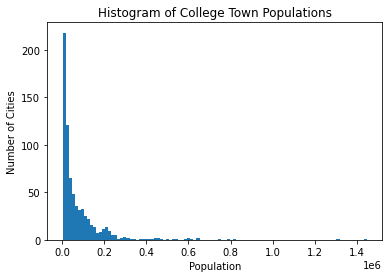

In [31]:
plt.title('Histogram of College Town Populations')
plt.xlabel('Population')
plt.ylabel('Number of Cities')
plt.hist(all_data_w_c.pop_2010, bins=100)
plt.show()

In [32]:
ninetyfive_ct = all_data_w_c.loc[ (all_data.pop_2010 <= all_data_w_c.pop_2010.quantile(.95)) ]

In [33]:
print( "Smallest college town 2010 population (lower 95%): {:.0f}".format( ninetyfive_ct.pop_2010.min() ) )
print( "Largest college town 2010 population (lower 95%): {:.0f}".format( ninetyfive_ct.pop_2010.max() ) )
print( "College towns with 2010 population (lower 95%): {:.0f}".format( ninetyfive_ct.pop_2010.count() ) )

Smallest college town 2010 population (lower 95%): 649
Largest college town 2010 population (lower 95%): 257452
College towns with 2010 population (lower 95%): 685


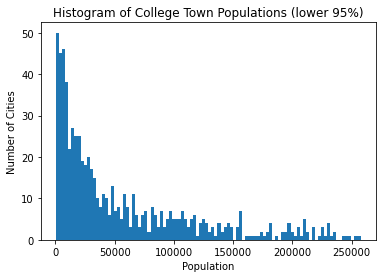

In [34]:
plt.title('Histogram of College Town Populations (lower 95%)')
plt.xlabel('Population')
plt.ylabel('Number of Cities')
plt.hist(ninetyfive_ct.pop_2010, bins=100)
plt.show()

## Comparing similarly sized Cities

From here forward, when comparing college town populations to the larger population data I will limit the dataset to cities with a known population of less than 250,000 so as to be comparing like samples.

In [35]:
dataset = all_data.loc[ ( all_data.pop_2010 < 250000 ) & (all_data['2020-09-30'] > 0)].drop(columns=['SizeRank', 'colleges'])

In [36]:
print( dataset.head() )

           city  1996-01-31  1996-02-29  1996-03-31  1996-04-30  1996-05-31  \
20      Orlando      107166      107259      107439      107704      108108   
52    Knoxville       99599       99881      100134      100555      100909   
53  Baton Rouge           0           0           0           0           0   
63     Columbia       90962       91033       91094       91250       91368   
65     Marietta      147940      148096      148384      148971      149705   

    1996-06-30  1996-07-31  1996-08-31  1996-09-30  ...  pop_2011  pop_2012  \
20      108442      108731      108823      108903  ...  243620.0  249935.0   
52      101327      101728      102191      102503  ...  179955.0  181093.0   
53           0           0           0           0  ...  228643.0  228889.0   
63       91484       91589       91821       92056  ...  131302.0  131761.0   
65      150394      150972      151473      151938  ...   57348.0   58167.0   

    pop_2013  pop_2014  pop_2015  pop_2016  pop_20

In [37]:
# Save the final dataset
dataset.to_csv('working_dataset.csv')